# Solving a regression problem using decision trees and random forests

In this lab we'll use tow different kinds of machine learning methods to solve a regression problem. The considered problem is one for which the data set can be loaded directly using scikit-learn.

More about

*   Decision Trees - [scikit-learn](https://scikit-learn.org/stable/modules/tree.html)
*   Random Forests - [scikit-learn](https://scikit-learn.org/stable/modules/ensemble.html#random-forests-and-other-randomized-tree-ensembles)

## 1 - Some metrics used with regression problems

Suppose we want to evaluate these metrics on a set (assuming a single output value)
$$\left(Y_j,Y^t_j\right)_{j \in \{1,\dots,n\}}$$ where $Y_j$ is the predicted output and $Y^t_j$ the original target output.

*   **Max Error** defined as $\mbox{ME}=\max_{j \in \{1,\dots,n\}} |Y_j-Y^t_j|$. Unfortunately usually it is does correctly reflect the performance.
*   **Mean Absolute Error** defined as $\mbox{MAE}=\frac{1}{n} \sum_{j \in \{1,\dots,n\}} |Y_j-Y^t_j|$
*   **Mean Squared Error** defined as $\mbox{MSE}=\frac{1}{n} \sum_{j \in \{1,\dots,n\}} (Y_j-Y^t_j)^2$
*   **$R^2$ score** is defined by $$R^2 = 1 - \frac{\sum_{j \in \{1,\dots,n\}}\left(Y_j-Y^t_j\right)^2}{\sum_{j \in \{1,\dots,n\}} \left(\bar{Y}-Y^t_j\right)^2}$$ where $\bar{Y}$ represents the mean of $Y_j$.
$R^2$ is between $0$ and $1$ and the closer it is to $1$, the best the classifier.



## 2 - Decision Trees learning explained: [Machine Learning / David Gerbing](https://web.pdx.edu/~gerbing/Books/ML/) and [Wikipedia](https://en.wikipedia.org/wiki/Decision_tree_learning)

## 3 - Random Forests explained : [Wikipedia](https://en.wikipedia.org/wiki/Random_forest)


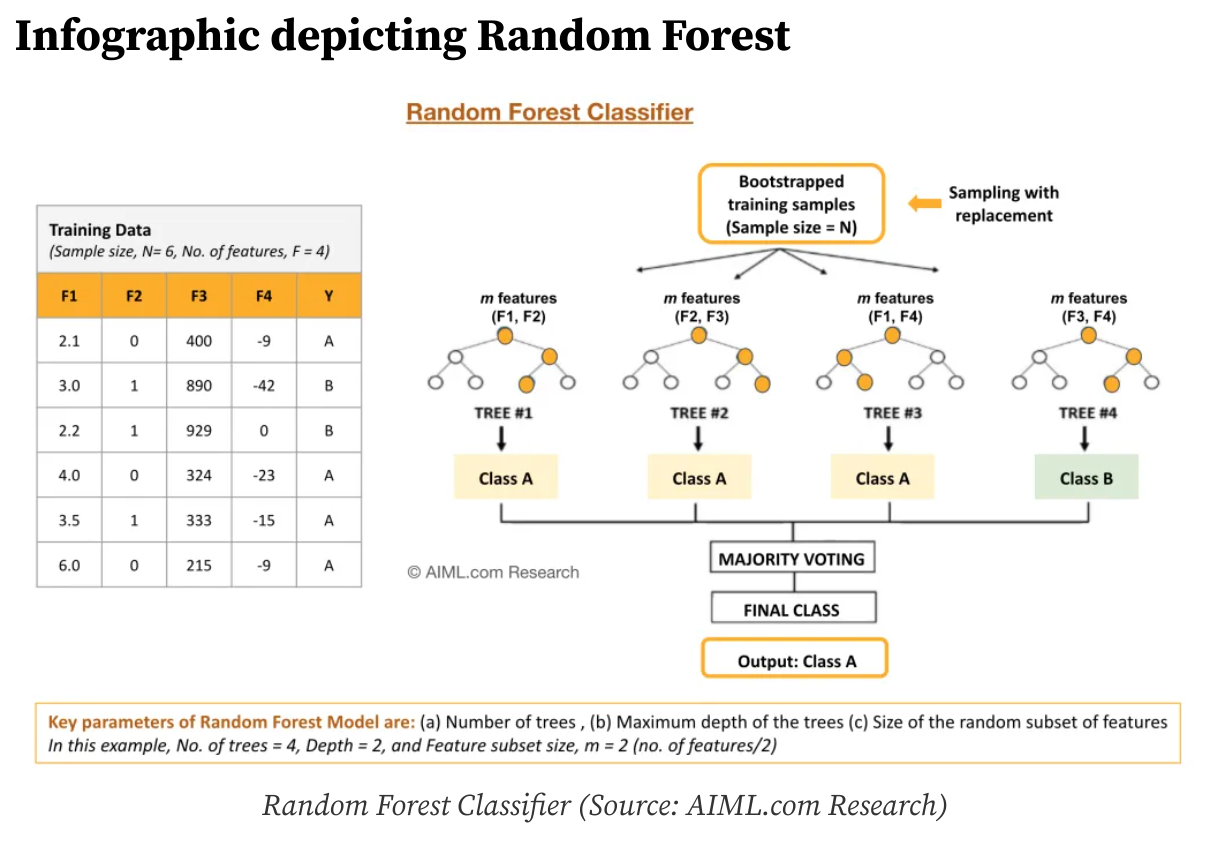

# What are you going to do?

In this Colab notebook you have to complete following steps:
1.   Load the boston data set. What kind of data does it contain?
2.   Train a regression Decision Tree to predict real estate value.
3.   Train several decision trees using increasing max_depth values.
4.   Train Random Forests by varying the max_depth value as done previously for decision tree.
5.   Show that scikit-learn simply averages the trees predictions of the forest.
6.   Rather than averaging the predictions of the different trees, uses Linear Regression to give them different weights
7.


## 1 - Load the boston data set

In [ ]:
#from sklearn.datasets import load_boston
#data = load_boston()
#X, y = data.data, data.target

 **Note on the Boston Housing Dataset:**
The `load_boston` function was deprecated and fully removed from `scikit-learn` as of version 1.2. The dataset contains an ethical issue regarding the engineered "B" variable, which was calculated using the formula $1000(Bk - 0.63)^2$, where $Bk$ represents the proportion of Black residents by town. This mathematical transformation encoded an assumption that racial self-segregation had a positive impact on house prices. Due to this baked-in bias, the library no longer distributes the dataset.

To complete this lab, the original `housing.csv` dataset has been uploaded to the session storage and loaded manually using `pandas`.

In [ ]:
import pandas as pd
import numpy as np

# 1 - Load the dataset from the uploaded housing.csv file
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('/content/housing.csv', delim_whitespace=True, header=None, names=columns)

# 2 - Define X and y
X = df.drop('MEDV', axis=1).values
y = df['MEDV'].values

/tmp/ipykernel_3071/3809064404.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('/content/housing.csv', delim_whitespace=True, header=None, names=columns)


The inputs / features names are as follows:

* CRIM - per capita crime rate by town

* ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

* INDUS - proportion of non-retail business acres per town.

* CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

* NOX - nitric oxides concentration (parts per 10 million)

* RM - average number of rooms per dwelling

* AGE - proportion of owner-occupied units built prior to 1940

* DIS - weighted distances to five Boston employment centres

* RAD - index of accessibility to radial highways

* TAX - full-value property-tax rate per $10,000

* PTRATIO - pupil-teacher ratio by town

* B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town

* LSTAT - % lower status of the population

* MEDV - Median value of owner-occupied homes in $1000's

In [ ]:
# 3 - Display the inputs and output of the first data sample
print("Inputs (X):", X[0])
print("Output (y):", y[0])


Inputs (X): [6.320e-03 1.800e+01 2.310e+00 0.000e+00 5.380e-01 6.575e+00 6.520e+01
 4.090e+00 1.000e+00 2.960e+02 1.530e+01 3.969e+02 4.980e+00]
Output (y): 24.0


In [ ]:
# 4 - Split data set into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2 - Train a regression decision tree to predict real estate value, plot the tree, and the importance of each of inputs / features. Evaluate the tree with $\mbox{MSE}$ and $R^2$ on both train and test sets.
Use scikit-learn's tree API to evaluate with $\mbox{MSE}$ and $R^2$.

In [ ]:
# 1 - Import MSE and R^2 from scikit-learn's API
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
# 2 - Train regressor decision tree using max_depth value of 2
rdt = DecisionTreeRegressor(max_depth=2, random_state=42)
rdt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [ ]:
# 3 - Predict values for the test set
y_pred = rdt.predict(X_test)

In [ ]:
# 4 - Print MSE and R^2 errors / metrics for test set
print('MSE : {}'.format(mean_squared_error(y_test, y_pred)))
print('R2 : {}'.format(r2_score(y_test, y_pred)))

MSE : 25.993190895971196
R2 : 0.6455495710736121


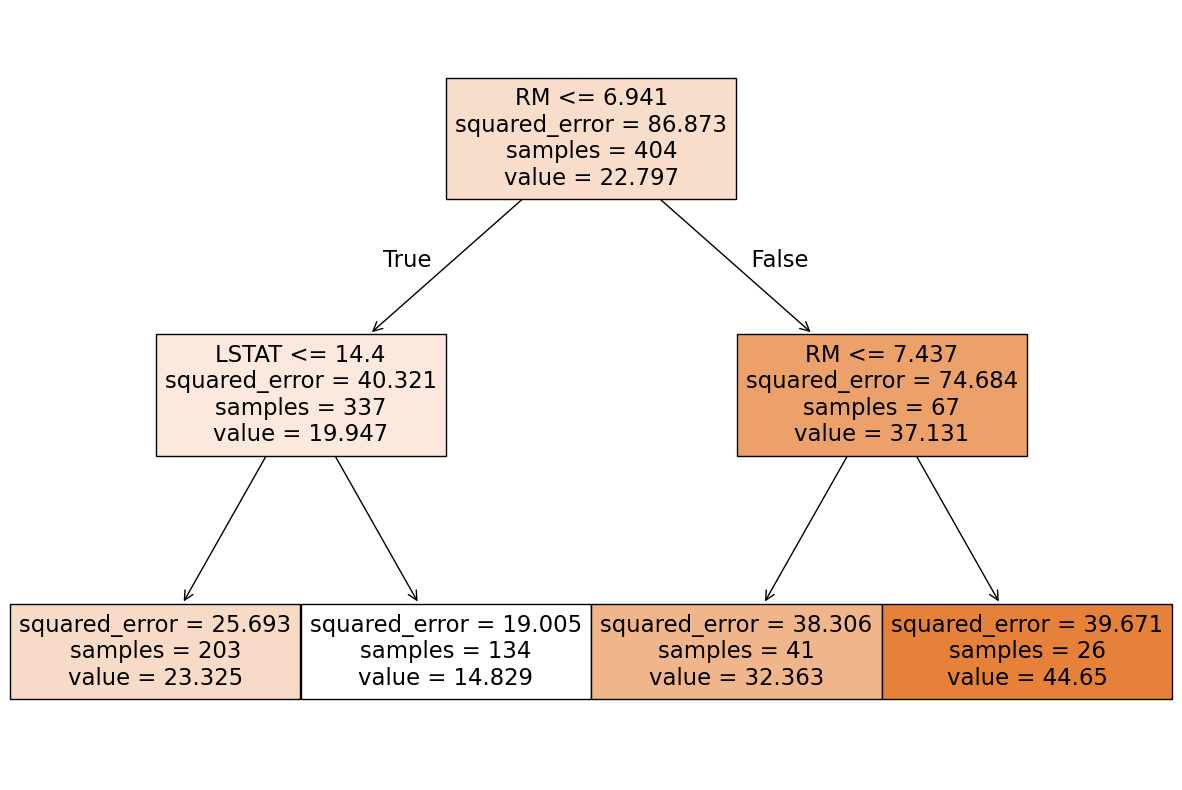

In [ ]:
# 5 - Use plot_tree from tree API to display the rules of the decision tree
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(rdt, feature_names=columns[:-1], filled=True)
plt.show()

Which inputs / features are the most important?

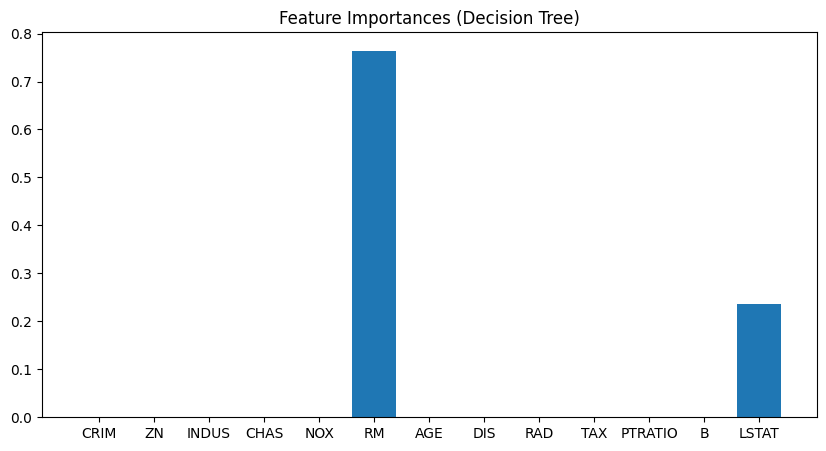

In [ ]:
# 6 - Use features_importances values of the decision tree to plot an histogram
plt.figure(figsize=(10,5))
plt.bar(columns[:-1], rdt.feature_importances_)
plt.title("Feature Importances (Decision Tree)")
plt.show()

## 3 - Train several decision trees using increasing max_depth values: 50 trees using max_depth values from 1 to 50. Save $\mbox{MSE}$ and $R^2$ values evaluated on train and test sets for each DT. Once the 50 DTs have been trained, plot the curves of the two metrics according to the value of the decision tree maximum depth.

In [ ]:
# 1 - Define some useful variables
max_depth_ls = [i for i in range(1,50)]
mse_train = []
mse_test = []
r2_train = []
r2_test = []

In [ ]:
# 2 - Train the 50 DTs and save their respective MSE and R^2 values
for m in max_depth_ls:
    dt = DecisionTreeRegressor(max_depth=m, random_state=42)
    dt.fit(X_train, y_train)

    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    mse_train.append(mean_squared_error(y_train, y_pred_train))
    mse_test.append(mean_squared_error(y_test, y_pred_test))

    r2_train.append(r2_score(y_train, y_pred_train))
    r2_test.append(r2_score(y_test, y_pred_test))

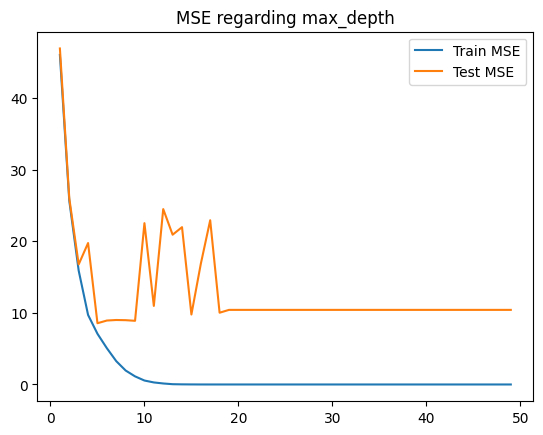

In [ ]:
# 3 - Plot the MSE tran and test curves according to max_depth
plt.figure()
plt.plot(max_depth_ls, mse_train, label='Train MSE')
plt.plot(max_depth_ls, mse_test, label='Test MSE')
plt.title('MSE regarding max_depth')
plt.legend()
plt.show()

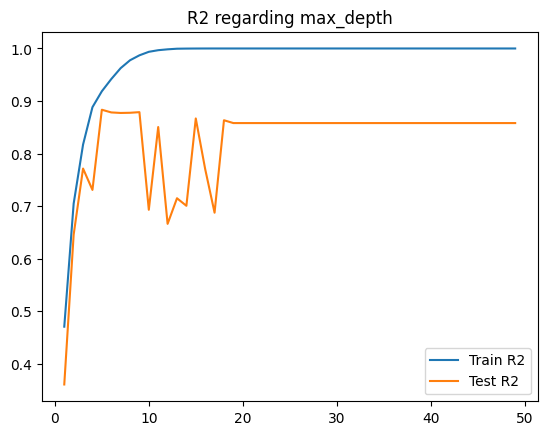

In [ ]:
# 4 - Plot the R^2 train and test curves according to max depth
plt.figure()
plt.plot(max_depth_ls, r2_train, label='Train R2')
plt.plot(max_depth_ls, r2_test, label='Test R2')
plt.title('R2 regarding max_depth')
plt.legend()
plt.show()

What can you observe? As the max_depth increases, the training MSE approaches 0 and training R² approaches 1, meaning the tree perfectly memorizes the training data. However, the Test MSE plateaus or slightly worsens, and Test R² stops improving. This is a classic visualization of overfitting.

## 4 - Now switch to random forests and continue to vary the max_depth value as done previously for decision tree. Use 100 and 0 as the n_estimators and random_state values, respectively.

In [ ]:
# 1 - Train a RF using 20 as max_depth value
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth=20, n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, random_state=0)

In [ ]:
# 2 - Print MSE and R^2 errors / metrics for test set
y_pred_rf = rf.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

MSE: 9.174068554952338
R2: 0.874899832524719


In [ ]:
# 3 - Train the 50 RFs and save their respective MSE and R^2 values
max_depth_ls = [i for i in range(1,50)]
mse_train = []
mse_test = []
r2_train = []
r2_test = []

for m in max_depth_ls :
    rf_loop = RandomForestRegressor(max_depth=m, n_estimators=100, random_state=0)
    rf_loop.fit(X_train, y_train)

    y_pred_train = rf_loop.predict(X_train)
    y_pred_test = rf_loop.predict(X_test)

    mse_train.append(mean_squared_error(y_train, y_pred_train))
    mse_test.append(mean_squared_error(y_test, y_pred_test))

    r2_train.append(r2_score(y_train, y_pred_train))
    r2_test.append(r2_score(y_test, y_pred_test))

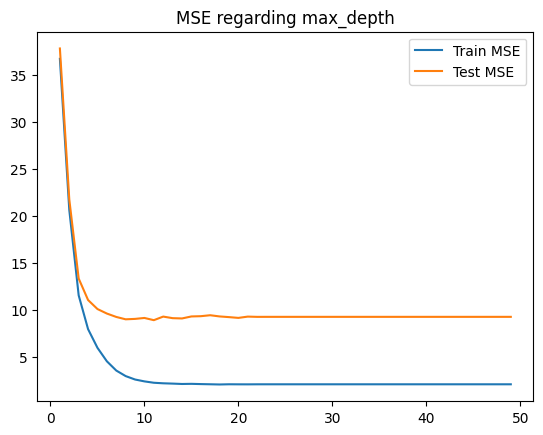

In [ ]:
# 4 - Plot the MSE tran and test curves according to max_depth
plt.figure()
plt.plot(max_depth_ls, mse_train, label='Train MSE')
plt.plot(max_depth_ls, mse_test, label='Test MSE')
plt.title('MSE regarding max_depth')
plt.legend()
plt.show()

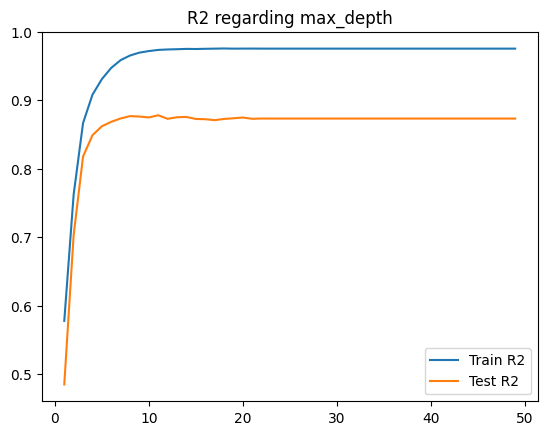

In [ ]:
# 5 - Plot the R^2 train and test curves according to max depth
plt.figure()
plt.plot(max_depth_ls, r2_train, label='Train R2')
plt.plot(max_depth_ls, r2_test, label='Test R2')
plt.title('R2 regarding max_depth')
plt.legend()
plt.show()

What can you observe? Unlike a single Decision Tree, the Random Forest does not overfit as severely. Even at high max_depth, the test MSE remains lower and test R² remains high and stable. Aggregating 100 trees reduces the variance significantly compared to a single tree.

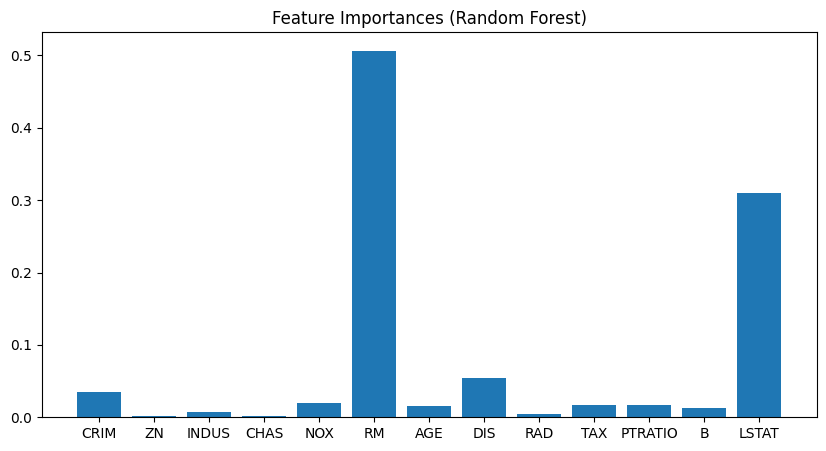

In [ ]:
# 6 - Use features_importances values of the last random forest to plot an histogram
plt.figure(figsize=(10,5))
plt.bar(columns[:-1], rf_loop.feature_importances_)
plt.title("Feature Importances (Random Forest)")
plt.show()

## 5 - Let us show that scikit-learn simply aggregates the trees predictions of the forest by computing their average value.

In [ ]:
import numpy as np
# 1 - Train a random forest with same parameters as above
rf_agg = RandomForestRegressor(max_depth=20, n_estimators=100, random_state=0)
rf_agg.fit(X_train, y_train)

# 2 - Get access to each tree of the forest using parameter estimators_
trees = rf_agg.estimators_

# 3 - Compute the average value of the predictions given by the different trees and use it to compute R^2
tree_predictions = np.array([tree.predict(X_test) for tree in trees])
avg_predictions = np.mean(tree_predictions, axis=0)
print("Averaged R2:", r2_score(y_test, avg_predictions))

Averaged R2: 0.874899832524719


In [ ]:
# 4 - Compute R^2 score using the predictions given by the Random Forest trained in step 1
print("RF R2:", r2_score(y_test, rf_agg.predict(X_test)))


RF R2: 0.874899832524719


## 6 - Rather than averaging the predictions of the different trees, let us try to learn how use different weights for the trees using a Linear Regression

The idea is to find the set of weights $w_1,\dots,w_B$  such that : $$ Y= P_{RF}(X) = \sum_{i=1,\dots,B} P_{DT_i} f_i(X)$$
where
* $B$ is the number of trees,
* $P_{RF}$ are the Random Forest's predictions,
* $P_{DT_i}$ are the predictions given by Decision Tree $i$.

In [ ]:
# 1 - Let us define a function that define the predictions given by the different DTs as the new features
def new_features(forest, X):
    # Returns an array of shape (samples, number of trees)
    return np.array([tree.predict(X) for tree in forest.estimators_]).T

In [ ]:
# 2 - Define new train and test sets
X_train2, X_test2 = new_features(rf_agg, X_train), new_features(rf_agg, X_test)

In [ ]:
# 3 - Train linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train2, y_train)

LinearRegression()

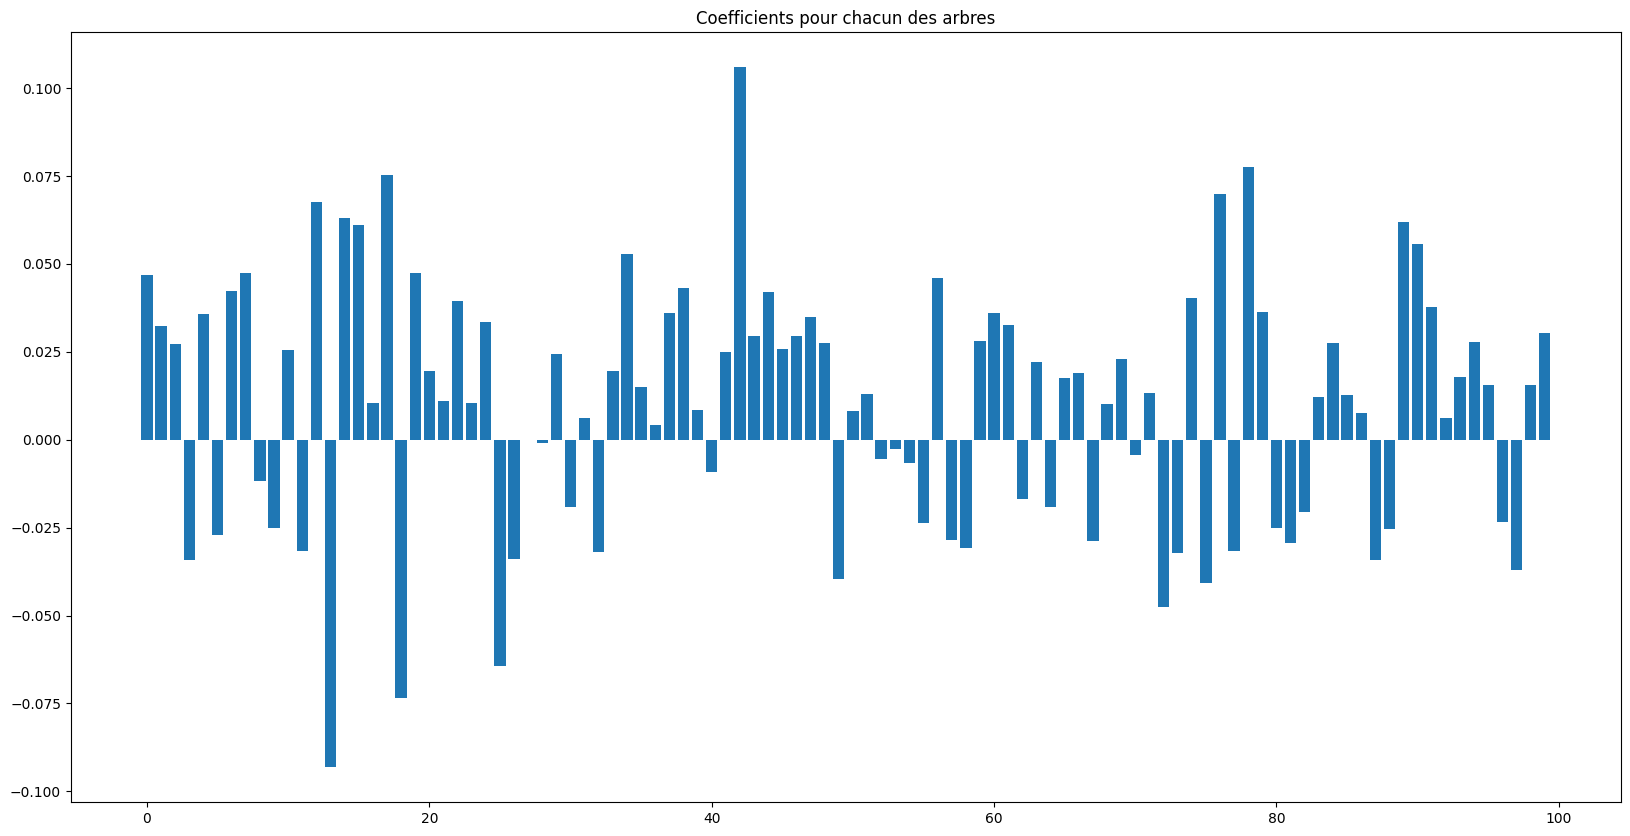

In [ ]:
# 4 - Show the weights values / linear regression coefficients
plt.figure(figsize=(20,10))
plt.bar(range(len(lr.coef_)), lr.coef_)
plt.title('Coefficients pour chacun des arbres')
plt.show()

In [ ]:
# 5 - Predict values for the new test set using linear regression
y_pred_lr = lr.predict(X_test2)

In [ ]:
# 6 - Print MSE and R^2 errors / metrics for the new test set
print("MSE with LR:", mean_squared_error(y_test, y_pred_lr))
print("R2 with LR:", r2_score(y_test, y_pred_lr))

MSE with LR: 7.8155136951178745
R2 with LR: 0.8934254669770475


## 7 - Try to replace Linear Regression with Lasso Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.597e+02, tolerance: 3.510e+00
  model = cd_fast.enet_coordinate_descent(


MSE with Lasso: 7.891322555971871
R2 with Lasso: 0.8923917161246162


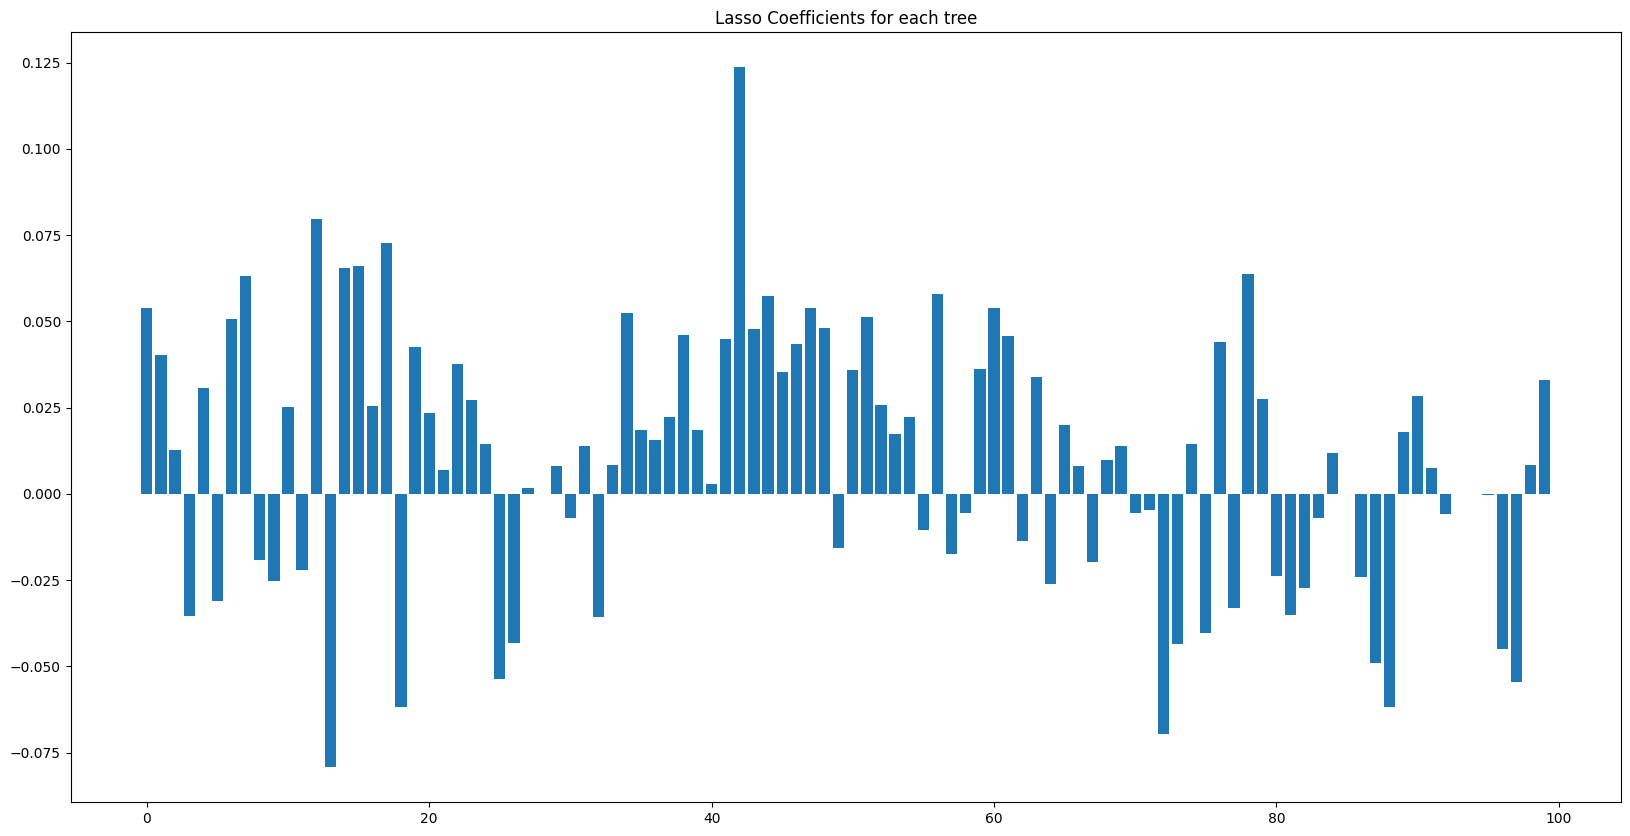

In [ ]:
# 7 - Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_train2, y_train)
y_pred_lasso = lasso.predict(X_test2)

print("MSE with Lasso:", mean_squared_error(y_test, y_pred_lasso))
print("R2 with Lasso:", r2_score(y_test, y_pred_lasso))

plt.figure(figsize=(20,10))
plt.bar(range(len(lasso.coef_)), lasso.coef_)
plt.title('Lasso Coefficients for each tree')
plt.show()